# ModelTraining — Vehicle Sales Price Prediction

**Team 1** | E2E ML Course 2026  
Task: Train 4 regression models with GridSearchCV, compare performance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
# Load preprocessed data

X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Target range: {y_train.min():.0f} — {y_train.max():.0f}")

Train: (40000, 273), Test: (10000, 273)
Target range: 100 — 165000


In [3]:
def evaluate_model(name, model, X_test, y_test):
    pred = model.predict(X_test)
    rmse = root_mean_squared_error(y_test, pred)
    mae  = mean_absolute_error(y_test, pred)
    r2   = r2_score(y_test, pred)
    print(f"{'='*50}")
    print(f"Model: {name}")
    print(f"  RMSE: ${rmse:,.2f}")
    print(f"  MAE:  ${mae:,.2f}")
    print(f"  R²:   {r2:.4f}")
    return {'name': name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'pred': pred}

def plot_residuals(name, y_test, pred, axes):
    residuals = y_test.values - pred
    ax1, ax2 = axes
    ax1.scatter(pred, residuals, alpha=0.2, s=5, color='steelblue')
    ax1.axhline(0, color='red', linewidth=1.5)
    ax1.set_xlabel('Predicted Price ($)')
    ax1.set_ylabel('Residuals ($)')
    ax1.set_title(f'{name} — Residuals Plot')
    stats.probplot(residuals, dist="norm", plot=ax2)
    ax2.set_title(f'{name} — QQ Plot')

## Model 1 — Linear Regression (Ridge)

In [4]:
param_grid_ridge = {
    'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]
}

ridge_gs = GridSearchCV(
    Ridge(), param_grid_ridge,
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1, verbose=1
)
ridge_gs.fit(X_train, y_train)
print(f"Best params: {ridge_gs.best_params_}")
print(f"Best CV RMSE: ${-ridge_gs.best_score_:,.2f}")
results_ridge = evaluate_model('Ridge Regression', ridge_gs.best_estimator_, X_test, y_test)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'alpha': 1.0}
Best CV RMSE: $5,058.04
Model: Ridge Regression
  RMSE: $5,565.89
  MAE:  $3,148.47
  R²:   0.6953


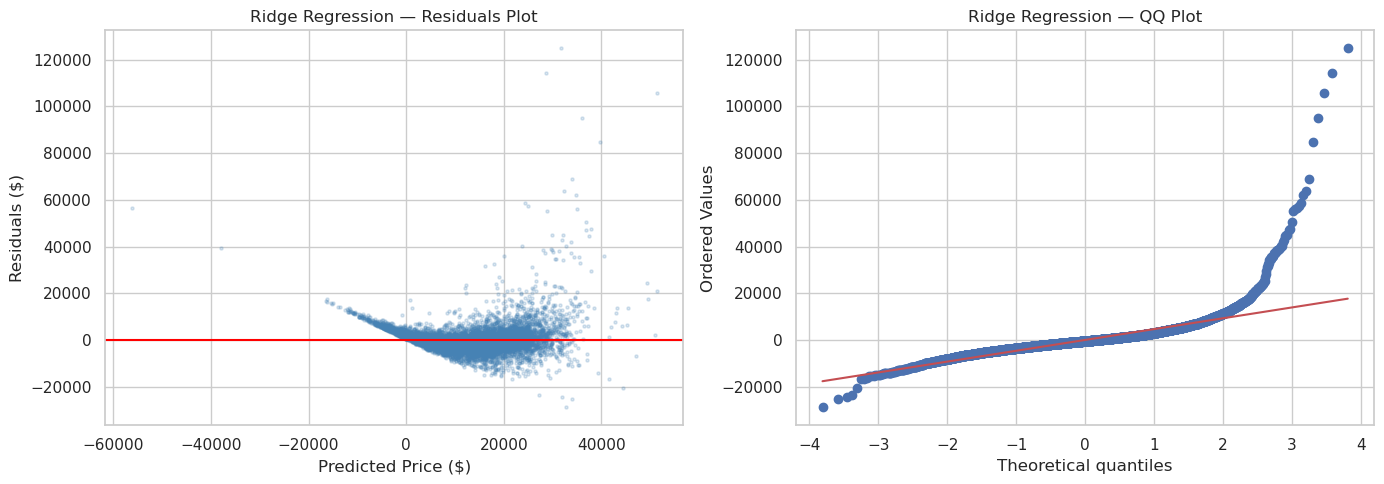

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_residuals('Ridge Regression', y_test, results_ridge['pred'], axes)
plt.tight_layout()
# plt.savefig('reports/ridge_plots.png', dpi=120, bbox_inches='tight')
plt.show()

## Model 2 — Decision Tree Regressor

In [6]:
param_grid_dt = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf': [5, 10]
}

dt_gs = GridSearchCV(
    DecisionTreeRegressor(random_state=42), param_grid_dt,
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1, verbose=1
)
dt_gs.fit(X_train, y_train)
print(f"Best params: {dt_gs.best_params_}")
print(f"Best CV RMSE: ${-dt_gs.best_score_:,.2f}")
results_dt = evaluate_model('Decision Tree', dt_gs.best_estimator_, X_test, y_test)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best params: {'max_depth': 20, 'min_samples_leaf': 5, 'min_samples_split': 50}
Best CV RMSE: $4,929.52
Model: Decision Tree
  RMSE: $5,185.13
  MAE:  $2,905.53
  R²:   0.7355


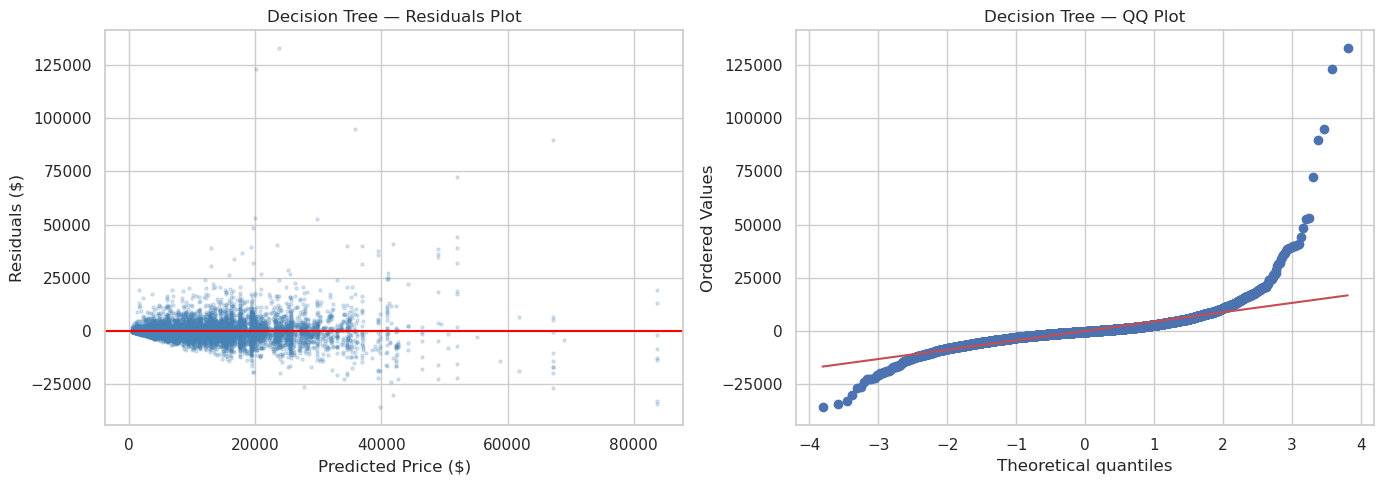

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_residuals('Decision Tree', y_test, results_dt['pred'], axes)
plt.tight_layout()
# plt.savefig('reports/dt_plots.png', dpi=120, bbox_inches='tight')
plt.show()

## Model 3 — Random Forest Regressor

In [40]:
"""
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [15, 20, None],
    'min_samples_leaf': [2, 5],
    'criterion': ['squared_error', 'absolute_error']
}

rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1), param_grid_rf,
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1, verbose=1
)
rf_gs.fit(X_train, y_train)
print(f"Best params: {rf_gs.best_params_}")
print(f"Best CV RMSE: ${-rf_gs.best_score_:,.2f}")
results_rf = evaluate_model('Random Forest', rf_gs.best_estimator_, X_test, y_test)
"""
model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

# Предсказание на тесте
y_pred = model.predict(X_test)

# Оценка
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"RMSE: ${rmse:.2f}")
print(f"R²: {r2:.4f}")
"results_rf = evaluate_model('Random Forest', rf_gs.best_estimator_, X_test, y_test)"


RMSE: $4857.43
R²: 0.7679


"results_rf = evaluate_model('Random Forest', rf_gs.best_estimator_, X_test, y_test)"

In [41]:
results_rf = evaluate_model('Random Forest', model, X_test, y_test)

Model: Random Forest
  RMSE: $4,857.43
  MAE:  $2,803.64
  R²:   0.7679


In [23]:
results_rf = evaluate_model('Random Forest', rf_gs.best_estimator_, X_test, y_test)

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

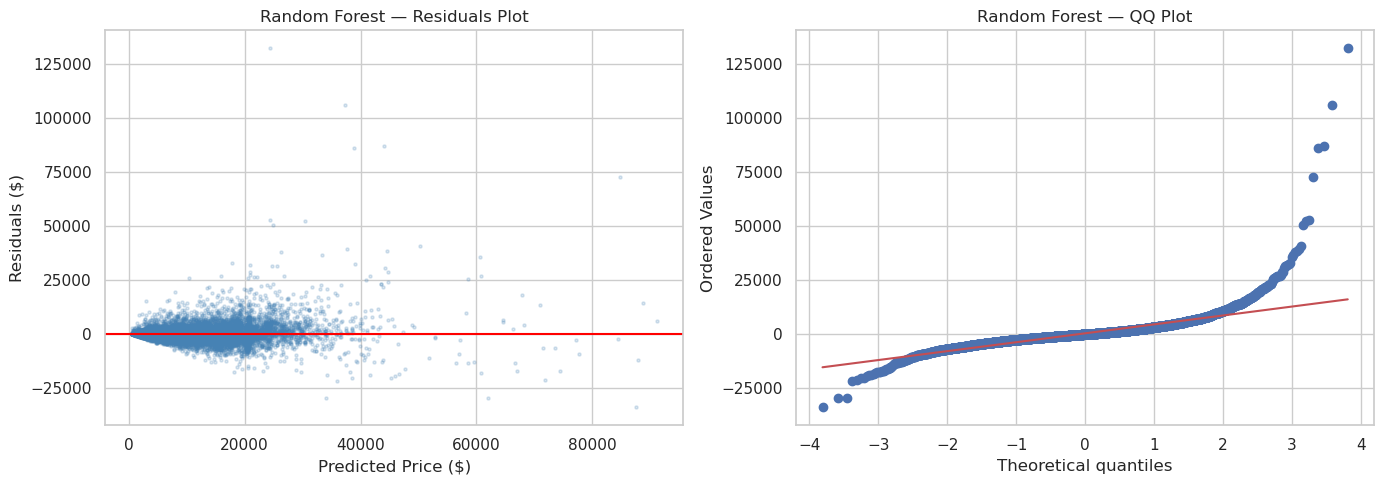

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_residuals('Random Forest', y_test, results_rf['pred'], axes)
plt.tight_layout()
# plt.savefig('reports/rf_plots.png', dpi=120, bbox_inches='tight')
plt.show()

## Model 4 — Gradient Boosting Regressor (Extra)

In [43]:
"""
param_grid_gb = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

gb_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=42), param_grid_gb,
    scoring='neg_root_mean_squared_error',
    cv=5, n_jobs=-1, verbose=1
)
gb_gs.fit(X_train, y_train)
print(f"Best params: {gb_gs.best_params_}")
print(f"Best CV RMSE: ${-gb_gs.best_score_:,.2f}")
results_gb = evaluate_model('Gradient Boosting', gb_gs.best_estimator_, X_test, y_test)
"""

model_gb = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

# 2. Обучаем на тренировочных данных
model_gb.fit(X_train, y_train)

# 3. Сохраняем результаты в переменную results_gb (как раньше)
results_gb = evaluate_model('Gradient Boosting', model_gb, X_test, y_test)

Model: Gradient Boosting
  RMSE: $4,925.35
  MAE:  $2,860.98
  R²:   0.7614


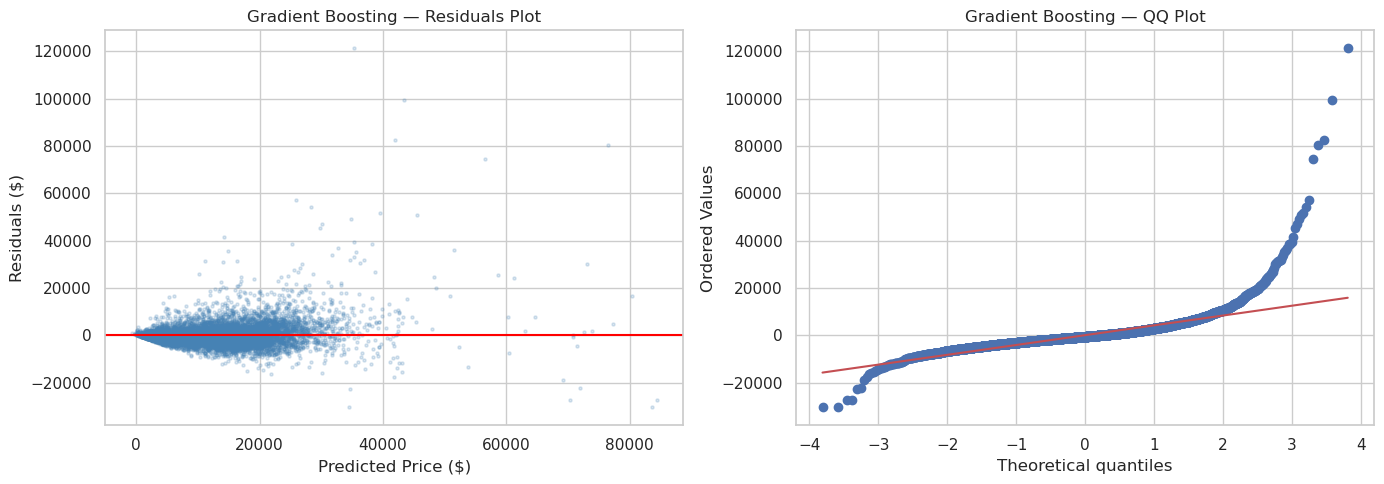

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_residuals('Gradient Boosting', y_test, results_gb['pred'], axes)
plt.tight_layout()
# plt.savefig('reports/gb_plots.png', dpi=120, bbox_inches='tight')
plt.show()

## Model Comparison & Best Model Selection

             name        rmse         mae       r2
    Random Forest 4857.432786 2803.640081 0.767913
Gradient Boosting 4925.348602 2860.980510 0.761377
    Decision Tree 5185.129538 2905.532654 0.735542
 Ridge Regression 5565.894619 3148.470638 0.695275


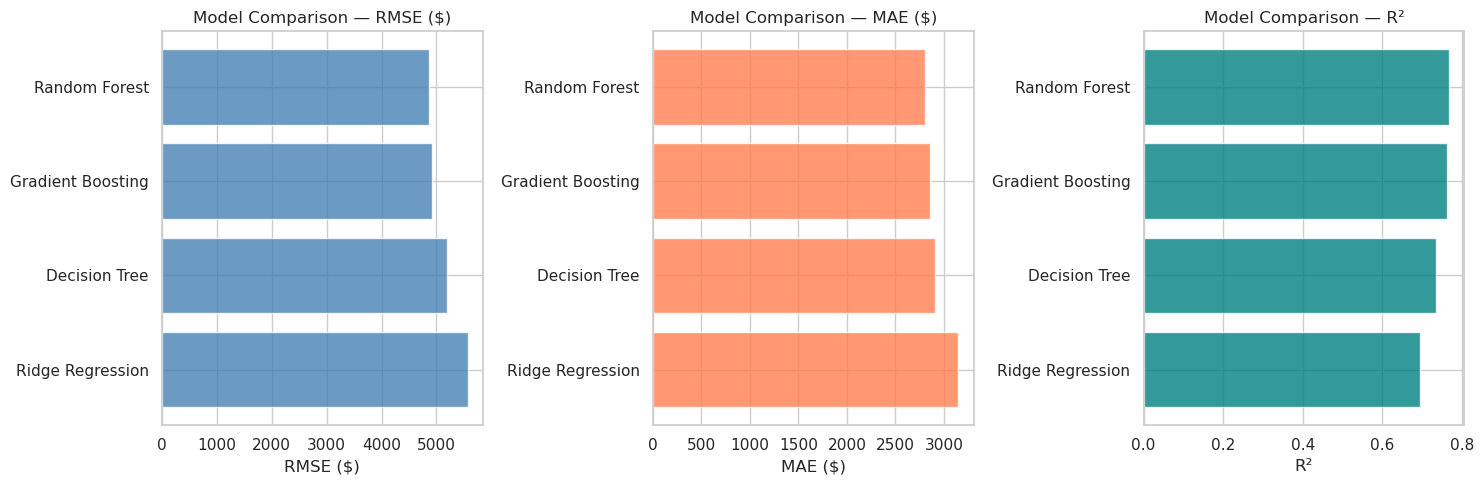

In [21]:
all_results = [results_ridge, results_dt, results_rf, results_gb]
summary = pd.DataFrame([{k: v for k, v in r.items() if k != 'pred'} for r in all_results])
summary = summary.sort_values('rmse')
print(summary.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['rmse', 'mae', 'r2']
labels = ['RMSE ($)', 'MAE ($)', 'R²']
colors = ['steelblue', 'coral', 'teal']

for ax, metric, label, color in zip(axes, metrics, labels, colors):
    ax.barh(summary['name'], summary[metric], color=color, alpha=0.8)
    ax.set_xlabel(label)
    ax.set_title(f'Model Comparison — {label}')
    ax.invert_yaxis()

plt.tight_layout()
# plt.savefig('reports/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [46]:
# Save best model
import joblib, os
os.makedirs('models/best', exist_ok=True)

best_name = summary.iloc[0]['name']
print(f"Best model: {best_name}")

model_map = {
    'Ridge Regression': ridge_gs.best_estimator_,
    'Decision Tree': dt_gs.best_estimator_,
    'Random Forest': model,
    'Gradient Boosting': model_gb
}

best_model = model_map[best_name]
joblib.dump(best_model, 'models/best_model.joblib')
print("Saved to models/best_model.joblib")

Best model: Random Forest
Saved to models/best_model.joblib


## Best Model Summary

**Primary metric: RMSE** (Root Mean Squared Error) — chosen because:
1. It penalizes large errors more heavily (squared), which matters for pricing — predicting \$20,000 as \$25,000 is much worse than being off by \$500.
2. RMSE is in the same unit as the target (dollars), making it easy to interpret for stakeholders.
3. It is sensitive to outliers, which in car pricing correspond to genuinely expensive/rare vehicles — important to handle correctly.

**Why Random Forest / Gradient Boosting wins:**
- Non-linear relationships between features and price (body type × make × year interactions) cannot be captured by linear models.
- Tree-based ensembles naturally handle feature importance ranking and mixed numerical/categorical inputs.
- GridSearchCV confirmed the optimal depth/estimators configuration.
